# Train

Crear el split, exportar `train/test` y entrenar el modelo.


Importa las dependencias necesarias para el notebook.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data.eda import load_processed_dataset
from src.training.split import make_train_test_split
from src.training.dataset import export_train_test_data
from src.training.train import load_train_arrays, train_tabular_model, save_trained_pipeline
from src.training.hyperparam_search import run_hyperparameter_search
from src.project_config import resolve_train_config


Carga la configuración del proceso de entrenamiento y evaluación.


In [2]:
cfg = resolve_train_config("/home/dani/github/profecia/config/train.toml")

PROCESSED_DIR = cfg["processed_dir"]
MODEL_BASE_DIR = cfg["model_base_dir"]
MODEL_DIR = cfg["model_dir"]
DATA_DIR = cfg["model_data_dir"]
ARTIFACTS_DIR = cfg["model_artifacts_dir"]
VARIABLE_NAMES = cfg["variable_names"]
PREDICTOR_NAMES = cfg["predictor_names"]
TARGET_NAME = cfg["target_name"]
split_mode = cfg["split_mode"]
train_fraction = cfg["train_fraction"]
test_fraction = cfg["test_fraction"]
min_valid_fraction = cfg["min_valid_fraction"]
seed = cfg["seed"]
model_name = cfg["model_name"]
scaler_name = cfg["scaler_name"]
random_state = cfg["random_state"]
mmap_mode = cfg["mmap_mode"]
model_params = cfg["model_params"]
cv_config = cfg["cv_config"]

print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODEL_BASE_DIR:", MODEL_BASE_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("DATA_DIR:", DATA_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("split_mode:", split_mode)
print("model_name:", model_name)
print("model_params:", model_params)
print("cv_config:", cv_config)


PROCESSED_DIR: /home/dani/github/profecia/data/processed/land_monthly
MODEL_BASE_DIR: /home/dani/github/profecia/data/models/hgb_land_monthly
MODEL_DIR: /home/dani/github/profecia/data/models/hgb_land_monthly/random_observation
DATA_DIR: /home/dani/github/profecia/data/models/hgb_land_monthly/random_observation/data
ARTIFACTS_DIR: /home/dani/github/profecia/data/models/hgb_land_monthly/random_observation/artifacts
split_mode: random_observation
model_name: hgb
model_params: {'loss': 'squared_error', 'learning_rate': 0.1, 'max_iter': 300, 'max_depth': 12, 'min_samples_leaf': 50}
cv_config: {'enabled': False, 'n_splits': 5, 'n_iter': 25, 'scoring': 'neg_root_mean_squared_error', 'n_jobs': 1, 'verbose': 1, 'search_space': {}}


Carga el dataset procesado y prepara las variables necesarias.


In [3]:
data_dict, metadata = load_processed_dataset(
    input_dir=PROCESSED_DIR,
    variable_names=VARIABLE_NAMES,
    reference_variable=TARGET_NAME,
)

target = data_dict[TARGET_NAME]
predictors = {name: data_dict[name] for name in PREDICTOR_NAMES}

print("Variables cargadas:", list(data_dict.keys()))
print("Shape target:", target.shape)
print("Periodo:", str(target.time.min().values)[:10], "->", str(target.time.max().values)[:10])


Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD', 'D2M', 'PEV']
Shape target: (492, 360, 720)
Periodo: 1982-01-01 -> 2022-12-01


Construye el split de train y test según la configuración activa.


In [4]:
split_result = make_train_test_split(
    split_mode=split_mode,
    target=target,
    predictors=predictors,
    train_fraction=train_fraction,
    test_fraction=test_fraction,
    seed=seed,
    min_valid_fraction=min_valid_fraction,
)

train_mask = split_result["train_mask"]
test_mask = split_result["test_mask"]
split_metadata = split_result["metadata"]

print(json.dumps(split_metadata, indent=2, ensure_ascii=False))


{
  "split_mode": "random_observation",
  "seed": 42,
  "train_fraction_requested": 0.1,
  "test_fraction_requested": 0.1,
  "min_valid_fraction": 0.0,
  "n_total_observations": 127526400,
  "n_valid_observations": 30831180,
  "n_selected_observations": 3083118,
  "n_train_observations": 2774806,
  "n_test_observations": 308312,
  "n_unique_train_pixels": 62665,
  "n_unique_test_pixels": 62239
}


Muestra una visualización rápida del split generado.


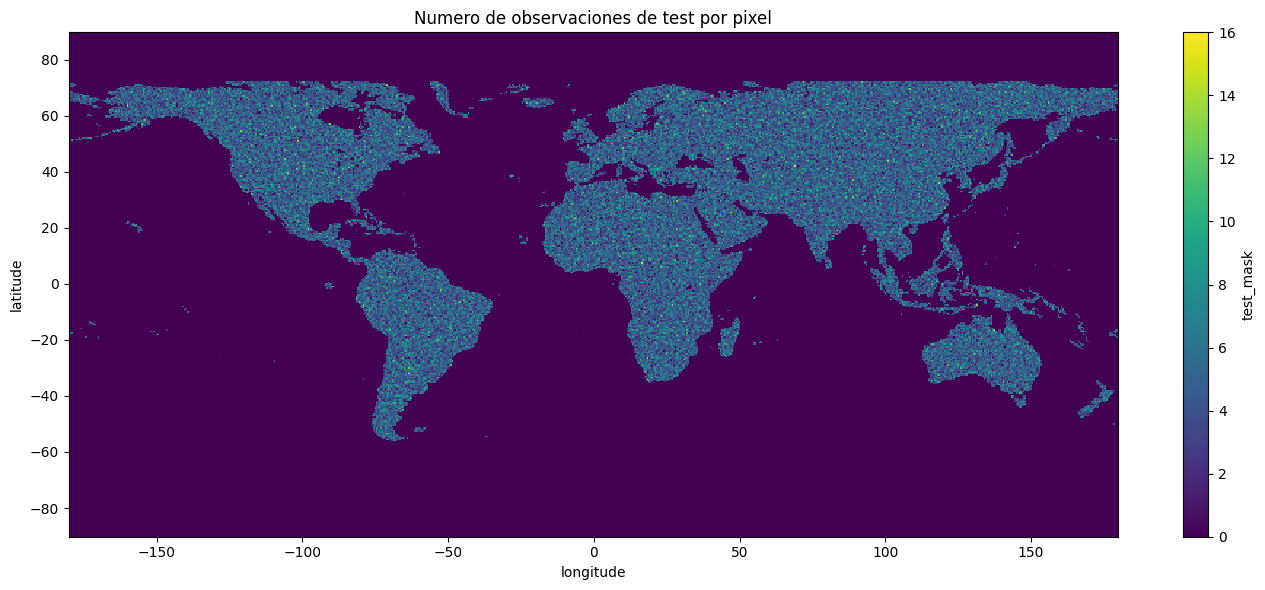

In [5]:
if split_mode == "spatial_pixel":
    fig, ax = plt.subplots(figsize=(14, 6))
    test_mask.astype(int).plot(ax=ax, cmap="RdYlGn")
    ax.set_title("Pixeles de test")
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    test_mask.sum(dim="time").plot(ax=ax, cmap="viridis")
    ax.set_title("Numero de observaciones de test por pixel")
    plt.tight_layout()
    plt.show()


Exporta los arrays de train/test y la metadata asociada al modelo.


In [6]:
dataset_metadata = export_train_test_data(
    target=target,
    predictors=predictors,
    train_mask=train_mask,
    test_mask=test_mask,
    output_dir=DATA_DIR,
    split_metadata=split_metadata,
    extra_masks={
        "valid_pixel_mask": split_result.get("valid_pixel_mask"),
        "selected_pixel_mask": split_result.get("selected_pixel_mask"),
        "selected_observation_mask": split_result.get("selected_observation_mask"),
        "valid_observation_mask": split_result.get("valid_observation_mask"),
    },
)

display(pd.DataFrame([dataset_metadata]))


,split_mode,n_train,n_test,n_unique_train_pixels,n_unique_test_pixels,n_features,feature_names,target,target_dtype,feature_dtypes,n_time,time_start,time_end,time_values,temporal_resolution_inferred,latitude_size,longitude_size,split_metadata
0,random_observation,2774806,308312,62665,62239,8,"[SM1, SM2, TP, T2M, SSRD, VPD, D2M, PEV]",LAI,float32,"{'SM1': 'float32', 'SM2': 'float32', 'TP': 'fl...",492,1982-01-01 00:00:00,2022-12-01 00:00:00,"[1982-01-01 00:00:00, 1982-02-01 00:00:00, 198...",monthly,360,720,"{'split_mode': 'random_observation', 'seed': 4..."


Carga los arrays tabulares de entrenamiento exportados.


In [7]:
X_train, y_train, train_trace, dataset_metadata = load_train_arrays(
    input_dir=DATA_DIR,
    mmap_mode=mmap_mode,
    return_trace=True,
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train trace keys:", list(train_trace.keys()))
print(json.dumps(dataset_metadata, indent=2, ensure_ascii=False))


X_train shape: (2774806, 8)
y_train shape: (2774806,)
train trace keys: ['pixel_id_train', 'lat_idx_train', 'lon_idx_train', 'time_idx_train']
{
  "split_mode": "random_observation",
  "n_train": 2774806,
  "n_test": 308312,
  "n_unique_train_pixels": 62665,
  "n_unique_test_pixels": 62239,
  "n_features": 8,
  "feature_names": [
    "SM1",
    "SM2",
    "TP",
    "T2M",
    "SSRD",
    "VPD",
    "D2M",
    "PEV"
  ],
  "target": "LAI",
  "target_dtype": "float32",
  "feature_dtypes": {
    "SM1": "float32",
    "SM2": "float32",
    "TP": "float32",
    "T2M": "float32",
    "SSRD": "float32",
    "VPD": "float32",
    "D2M": "float32",
    "PEV": "float32"
  },
  "n_time": 492,
  "time_start": "1982-01-01 00:00:00",
  "time_end": "2022-12-01 00:00:00",
  "time_values": [
    "1982-01-01 00:00:00",
    "1982-02-01 00:00:00",
    "1982-03-01 00:00:00",
    "1982-04-01 00:00:00",
    "1982-05-01 00:00:00",
    "1982-06-01 00:00:00",
    "1982-07-01 00:00:00",
    "1982-08-01 00:00:00"

Muestra un resumen rápido del estado actual del notebook.


In [8]:
assert X_train.ndim == 2
assert y_train.ndim == 1
assert X_train.shape[0] == y_train.shape[0]
assert X_train.shape[1] == dataset_metadata["n_features"]
assert dataset_metadata.get("split_mode") == split_mode
assert np.isnan(X_train).sum() == 0
assert np.isnan(y_train).sum() == 0

print("y_train min :", float(np.min(y_train)))
print("y_train max :", float(np.max(y_train)))
print("y_train mean:", float(np.mean(y_train)))
print("y_train std :", float(np.std(y_train)))


y_train min : 0.0
y_train max : 6.0333333015441895
y_train mean: 1.2296043634414673
y_train std : 1.36325204372406


Entrena el modelo configurado con los datos de entrenamiento.


In [9]:
final_model_params = dict(model_params)
hyperparameter_search_info = {"enabled": False}

if cv_config.get("enabled", False):
    cv_result = run_hyperparameter_search(
        X_train=X_train,
        y_train=y_train,
        split_mode=split_mode,
        model_name=model_name,
        scaler_name=scaler_name,
        random_state=random_state,
        base_model_params=model_params,
        search_space=cv_config["search_space"],
        pixel_id_train=train_trace["pixel_id_train"],
        cv_config=cv_config,
        output_dir=ARTIFACTS_DIR / "cv",
    )
    final_model_params.update(cv_result["best_params"])
    hyperparameter_search_info = cv_result["metadata"]
    display(cv_result["cv_results"].sort_values("rank_test_score").head(10))
    print("Best CV score:", cv_result["best_score"])
    print("Best params:", cv_result["best_params"])

train_result = train_tabular_model(
    X_train=X_train,
    y_train=y_train,
    model_name=model_name,
    scaler_name=scaler_name,
    random_state=random_state,
    **final_model_params,
)
train_result["train_info"]["hyperparameter_search"] = hyperparameter_search_info

print("Modelo entrenado:", train_result["train_info"]["model_name"])
print("Scaler:", train_result["train_info"]["scaler_name"])
train_result["train_info"]


Modelo entrenado: HistGradientBoostingRegressor
Scaler: none


{'model_name_requested': 'hgb',
 'model_name': 'HistGradientBoostingRegressor',
 'model_params': {'categorical_features': 'from_dtype',
  'early_stopping': 'auto',
  'interaction_cst': None,
  'l2_regularization': 0.0,
  'learning_rate': 0.1,
  'loss': 'squared_error',
  'max_bins': 255,
  'max_depth': 12,
  'max_features': 1.0,
  'max_iter': 300,
  'max_leaf_nodes': 31,
  'min_samples_leaf': 50,
  'monotonic_cst': None,
  'n_iter_no_change': 10,
  'quantile': None,
  'random_state': 42,
  'scoring': 'loss',
  'tol': 1e-07,
  'validation_fraction': 0.1,
  'verbose': 0,
  'warm_start': False},
 'scaler_name': 'none',
 'random_state': 42,
 'n_rows_train': 2774806,
 'n_features': 8,
 'X_dtype': 'float32',
 'y_dtype': 'float32',
 'mlflow_run_id': None,
 'mlflow_experiment': None,
 'hyperparameter_search': {'enabled': False}}

Guarda el modelo entrenado y su metadata en disco.


In [10]:
saved_paths = save_trained_pipeline(
    output_dir=ARTIFACTS_DIR,
    model=train_result["model"],
    scaler=train_result["scaler"],
    train_info=train_result["train_info"],
    dataset_metadata=dataset_metadata,
)

print(json.dumps(saved_paths, indent=2, ensure_ascii=False))


{
  "model_path": "/home/dani/github/profecia/data/models/hgb_land_monthly/random_observation/artifacts/model.joblib",
  "scaler_path": null,
  "train_info_path": "/home/dani/github/profecia/data/models/hgb_land_monthly/random_observation/artifacts/train_info.json"
}
